In [1]:
# ── Imports ────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

print('All imports successful.')










All imports successful.


In [2]:
def load_data():
    """
    Loads all five CSV files and parses date columns.
    Returns: train, stores, oil, transactions, holidays DataFrames
    """
    train        = pd.read_csv('train.csv')
    stores       = pd.read_csv('stores.csv')
    oil          = pd.read_csv('oil.csv')
    transactions = pd.read_csv('transactions.csv')
    holidays     = pd.read_csv('holidays_events.csv')

    # Convert date columns to datetime
    for df in [train, stores, oil, transactions, holidays]:
        if 'date' in df.columns:
            df['date'] = pd.to_datetime(df['date'])

    print('Shapes after loading:')
    print(f'  train        : {train.shape}')
    print(f'  stores       : {stores.shape}')
    print(f'  oil          : {oil.shape}')
    print(f'  transactions : {transactions.shape}')
    print(f'  holidays     : {holidays.shape}')

    return train, stores, oil, transactions, holidays


train, stores, oil, transactions, holidays = load_data()

Shapes after loading:
  train        : (1048575, 6)
  stores       : (54, 5)
  oil          : (1218, 2)
  transactions : (83488, 3)
  holidays     : (350, 6)


In [3]:
def basic_eda(df, name="Dataset"):
    print(f"\n===== {name} =====")

    # Shape
    print(f"\nShape (rows, cols): {df.shape}")

    # Data types
    print("\nData Types:")
    print(df.dtypes)

    # Missing values
    print("\nMissing Values:")
    missing = df.isnull().sum()
    print(missing[missing > 0] if missing.any() else "No missing values")

    # Summary statistics
    print("\nSummary Statistics:")
    print(df.describe())

    print("\n" + "="*50)


# Run EDA on all datasets
basic_eda(train, "Train")
basic_eda(stores, "Stores")
basic_eda(oil, "Oil")
basic_eda(transactions, "Transactions")
basic_eda(holidays, "Holidays")


===== Train =====

Shape (rows, cols): (1048575, 6)

Data Types:
id                      int64
date           datetime64[ns]
store_nbr               int64
family                 object
sales                 float64
onpromotion             int64
dtype: object

Missing Values:
No missing values

Summary Statistics:
                 id                           date     store_nbr  \
count  1.048575e+06                        1048575  1.048575e+06   
mean   5.242870e+05  2013-10-22 02:30:51.946499328  2.749256e+01   
min    0.000000e+00            2013-01-01 00:00:00  1.000000e+00   
25%    2.621435e+05            2013-05-28 00:00:00  1.400000e+01   
50%    5.242870e+05            2013-10-22 00:00:00  2.700000e+01   
75%    7.864305e+05            2014-03-19 00:00:00  4.100000e+01   
max    1.048574e+06            2014-08-13 00:00:00  5.400000e+01   
std    3.026977e+05                            NaN  1.558408e+01   

              sales   onpromotion  
count  1.048575e+06  1.048575e+06  

In [4]:
def merge_data(train, stores, oil, transactions, holidays):
    """
    Merges all 5 tables into one master DataFrame.
    Join strategy:
      - stores       : left join on store_nbr
      - oil          : left join on date
      - transactions : left join on [date, store_nbr]
      - holidays     : left join on date
    Sort by date after merging to restore chronological order.
    """
    df = train.copy()
    df = df.merge(stores,       on='store_nbr',           how='left')
    df = df.merge(oil,          on='date',                how='left')
    df = df.merge(transactions, on=['date', 'store_nbr'], how='left')
    df = df.merge(holidays,     on='date',                how='left')
    df = df.sort_values('date').reset_index(drop=True)

    print(f'Merged shape : {df.shape}')
    print(f'Columns      : {list(df.columns)}')
    return df


df = merge_data(train, stores, oil, transactions, holidays)
df.head()

Merged shape : (1064613, 17)
Columns      : ['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion', 'city', 'state', 'type_x', 'cluster', 'dcoilwtico', 'transactions', 'type_y', 'locale', 'locale_name', 'description', 'transferred']


,id,date,store_nbr,family,sales,onpromotion,city,state,type_x,cluster,dcoilwtico,transactions,type_y,locale,locale_name,description,transferred
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,False
1,1194,2013-01-01,42,CELEBRATION,0.0,0,Cuenca,Azuay,D,2,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,False
2,1193,2013-01-01,42,BREAD/BAKERY,0.0,0,Cuenca,Azuay,D,2,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,False
3,1192,2013-01-01,42,BOOKS,0.0,0,Cuenca,Azuay,D,2,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,False
4,1191,2013-01-01,42,BEVERAGES,0.0,0,Cuenca,Azuay,D,2,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,False


In [5]:
def clean_data(df):
    """
    Handles missing values and renames conflicting columns.

    Missing value strategies:
      - dcoilwtico   : ffill then bfill (oil markets closed on weekends/holidays)
      - transactions : median per store (missing on certain holiday dates)
      - holiday cols : fill with 'None' string; create binary is_holiday flag
      - transferred  : fill False, cast to int

    Outlier handling:
      - Sales capped at 99th percentile to remove extreme values
        that would dominate gradient updates during training.
    """
    # ── Rename clashing 'type' columns from stores + holidays merge ──
    if 'type_x' in df.columns:
        df = df.rename(columns={'type_x': 'store_type', 'type_y': 'holiday_type'})

    # ── Oil price: forward-fill then backward-fill ──────────────────
    df['dcoilwtico'] = df['dcoilwtico'].ffill().bfill()

    # ── Transactions: per-store median imputation ───────────────────
    df['transactions'] = df.groupby('store_nbr')['transactions'].transform(
        lambda x: x.fillna(x.median())
    )

    # ── Holiday columns: fill NaN, create binary flag ───────────────
    df['is_holiday']   = df['holiday_type'].notna().astype(int)
    df['holiday_type'] = df['holiday_type'].fillna('None')
    df['locale']       = df['locale'].fillna('None')
    df['transferred']  = df['transferred'].fillna(False).astype(int)

    # Drop unused holiday text columns (not useful as model features)
    drop_cols = ['locale_name', 'description', 'id']
    df = df.drop(columns=[c for c in drop_cols if c in df.columns])

    # ── Cap sales outliers at 99th percentile ───────────────────────
    cap_value = df['sales'].quantile(0.99)
    df['sales'] = np.where(df['sales'] > cap_value, cap_value, df['sales'])
    print(f'Sales capped at 99th percentile: {cap_value:.2f}')

    # ── Missing value check after cleaning ──────────────────────────
    missing = df.isnull().sum()
    print('\nMissing values after cleaning:')
    print(missing[missing > 0] if missing.any() else '  None — all clean!')

    return df


df = clean_data(df)
df.head()

Sales capped at 99th percentile: 3984.00

Missing values after cleaning:
transactions    118338
dtype: int64


,date,store_nbr,family,sales,onpromotion,city,state,store_type,cluster,dcoilwtico,transactions,holiday_type,locale,transferred,is_holiday
0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,93.14,1751.5,Holiday,National,0,1
1,2013-01-01,42,CELEBRATION,0.0,0,Cuenca,Azuay,D,2,93.14,NaN,Holiday,National,0,1
2,2013-01-01,42,BREAD/BAKERY,0.0,0,Cuenca,Azuay,D,2,93.14,NaN,Holiday,National,0,1
3,2013-01-01,42,BOOKS,0.0,0,Cuenca,Azuay,D,2,93.14,NaN,Holiday,National,0,1
4,2013-01-01,42,BEVERAGES,0.0,0,Cuenca,Azuay,D,2,93.14,NaN,Holiday,National,0,1



===== UNIVARIATE ANALYSIS =====


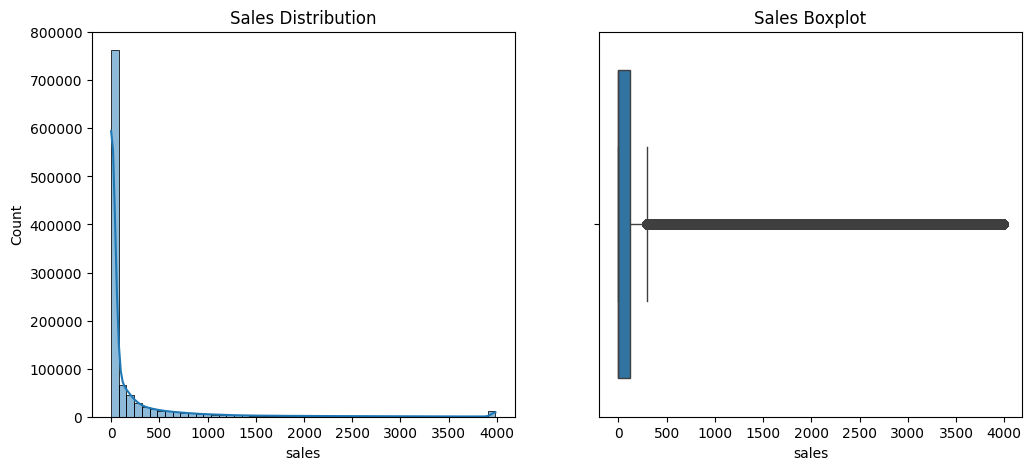

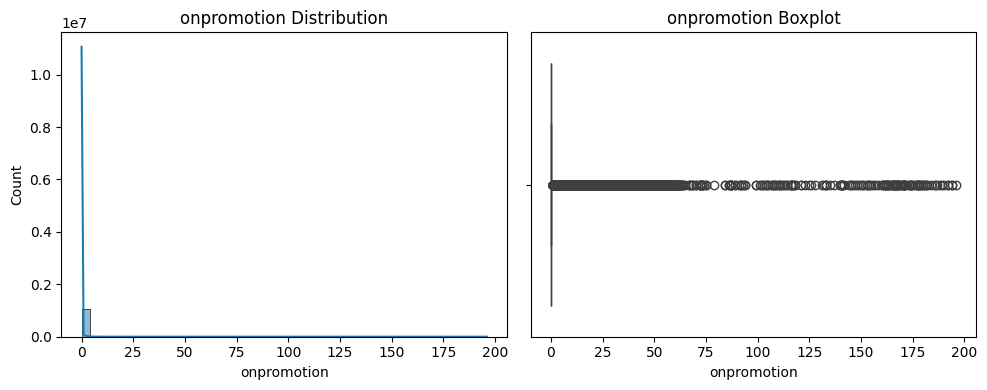

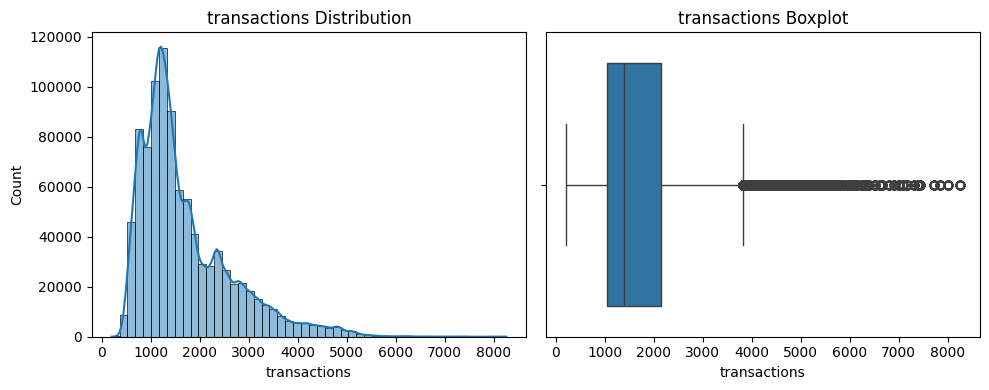

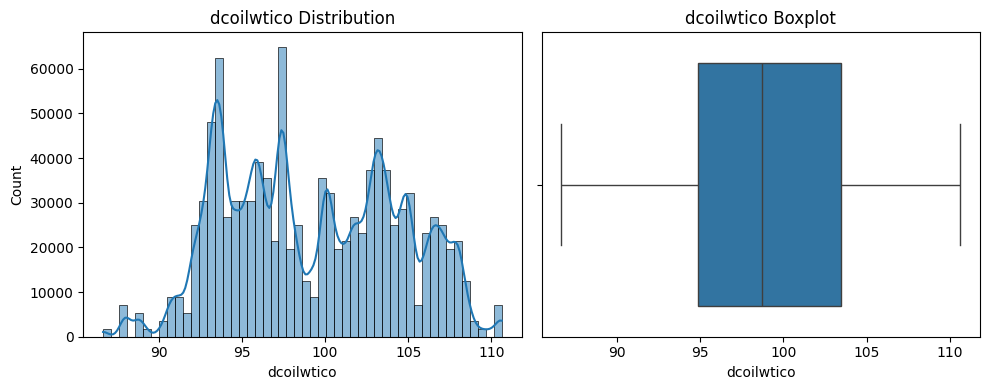

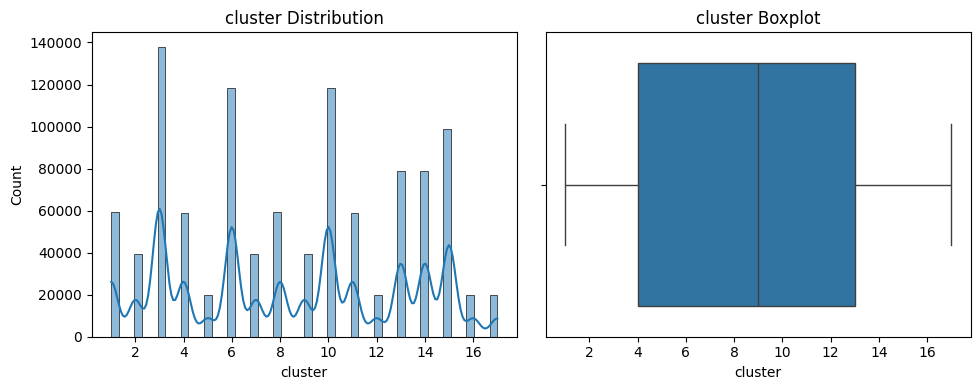

In [6]:
def univariate_analysis(df):
    print("\n===== UNIVARIATE ANALYSIS =====")

    # Target: Sales
    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    sns.histplot(df['sales'], bins=50, kde=True)
    plt.title('Sales Distribution')

    plt.subplot(1,2,2)
    sns.boxplot(x=df['sales'])
    plt.title('Sales Boxplot')

    plt.show()

    # Important Features
    important_features = [
        'onpromotion',
        'transactions',
        'dcoilwtico',
        'cluster'
    ]

    for col in important_features:
        if col in df.columns:
            plt.figure(figsize=(10,4))

            plt.subplot(1,2,1)
            sns.histplot(df[col], bins=50, kde=True)
            plt.title(f'{col} Distribution')

            plt.subplot(1,2,2)
            sns.boxplot(x=df[col])
            plt.title(f'{col} Boxplot')

            plt.tight_layout()
            plt.show()


# Run it
univariate_analysis(df)

In [7]:
def encode_categoricals(df):
    """
    Label-encodes all categorical string columns.
    LabelEncoder chosen over one-hot because:
      - XGBoost handles integer-encoded categories natively
      - One-hot on 'family' (33 levels) would add 33 extra columns

    Returns:
      df       : DataFrame with encoded columns
      encoders : dict of {column_name: fitted LabelEncoder}
                 (save these to decode predictions later if needed)
    """
    cat_cols = ['family', 'state', 'store_type', 'holiday_type', 'locale', 'city']
    encoders = {}

    for col in cat_cols:
        if col in df.columns:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col].astype(str))
            encoders[col] = le
            print(f'  Encoded: {col:15s} → {len(le.classes_)} unique classes')

    return df, encoders


df, encoders = encode_categoricals(df)
print('\nDtypes after encoding:')
print(df.dtypes)

  Encoded: family          → 33 unique classes
  Encoded: state           → 16 unique classes
  Encoded: store_type      → 5 unique classes
  Encoded: holiday_type    → 6 unique classes
  Encoded: locale          → 4 unique classes
  Encoded: city            → 22 unique classes

Dtypes after encoding:
date            datetime64[ns]
store_nbr                int64
family                   int64
sales                  float64
onpromotion              int64
city                     int64
state                    int64
store_type               int64
cluster                  int64
dcoilwtico             float64
transactions           float64
holiday_type             int64
locale                   int64
transferred              int64
is_holiday               int64
dtype: object


In [8]:
def engineer_features(df):
    """
    Creates all engineered features from the merged cleaned DataFrame.

    Feature groups:
      1. Date features        — year, month, day, day_of_week, etc.
      2. Cyclical encoding    — sin/cos of month and weekday
      3. Lag features         — past sales at 1, 7, 14, 30 day offsets
      4. Rolling statistics   — rolling mean/std over 7, 14, 30 day windows
      5. Trend features       — difference between lag values
      6. Interaction features — promotion × lag, holiday × promotion

    IMPORTANT: All lag/rolling ops use groupby(['store_nbr','family'])
    to prevent values leaking across different store-product series.
    """
    # Sort chronologically within each store-family group
    df = df.sort_values(['store_nbr', 'family', 'date']).reset_index(drop=True)

    # ── 1. Date features ────────────────────────────────────────────
    df['year']         = df['date'].dt.year
    df['month']        = df['date'].dt.month
    df['day']          = df['date'].dt.day
    df['day_of_week']  = df['date'].dt.dayofweek          # 0=Monday, 6=Sunday
    df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)
    df['is_weekend']   = df['day_of_week'].isin([5, 6]).astype(int)
    df['half_year']    = (df['month'] > 6).astype(int)

    # ── 2. Cyclical encoding ─────────────────────────────────────────
    # Converts circular features so Dec→Jan is treated as adjacent
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    df['week_sin']  = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['week_cos']  = np.cos(2 * np.pi * df['day_of_week'] / 7)

    # ── 3. Lag features (grouped per store-family series) ─────────────
    group = df.groupby(['store_nbr', 'family'])
    df['sales_lag_1']  = group['sales'].shift(1)
    df['sales_lag_7']  = group['sales'].shift(7)
    df['sales_lag_14'] = group['sales'].shift(14)
    df['sales_lag_30'] = group['sales'].shift(30)

    # ── 4. Rolling statistics ────────────────────────────────────────
    df['rolling_mean_7']  = group['sales'].transform(lambda x: x.rolling(7,  min_periods=1).mean())
    df['rolling_mean_14'] = group['sales'].transform(lambda x: x.rolling(14, min_periods=1).mean())
    df['rolling_mean_30'] = group['sales'].transform(lambda x: x.rolling(30, min_periods=1).mean())
    df['rolling_std_7']   = group['sales'].transform(lambda x: x.rolling(7,  min_periods=1).std())

    # ── 5. Trend features ────────────────────────────────────────────
    df['trend_7']  = df['sales_lag_1'] - df['sales_lag_7']   # short-term momentum
    df['trend_14'] = df['sales_lag_1'] - df['sales_lag_14']  # medium-term momentum

    # ── 6. Interaction features ──────────────────────────────────────
    df['promo_effect']  = df['onpromotion'] * df['sales_lag_1'].fillna(0)  # promo × recent sales
    df['holiday_promo'] = df['onpromotion'] * df['is_holiday']              # promo on a holiday
    df['store_family']  = df['store_nbr'].astype(str) + '_' + df['family'].astype(str)

    # ── Fill NaNs from lag/rolling (rows at the start of each series) ─
    df = df.fillna(0)

    print(f'Feature engineering complete.')
    print(f'Final shape : {df.shape}')
    print(f'Columns     : {list(df.columns)}')
    return df


df = engineer_features(df)
df.head()

Feature engineering complete.
Final shape : (1064613, 39)
Columns     : ['date', 'store_nbr', 'family', 'sales', 'onpromotion', 'city', 'state', 'store_type', 'cluster', 'dcoilwtico', 'transactions', 'holiday_type', 'locale', 'transferred', 'is_holiday', 'year', 'month', 'day', 'day_of_week', 'week_of_year', 'is_weekend', 'half_year', 'month_sin', 'month_cos', 'week_sin', 'week_cos', 'sales_lag_1', 'sales_lag_7', 'sales_lag_14', 'sales_lag_30', 'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_30', 'rolling_std_7', 'trend_7', 'trend_14', 'promo_effect', 'holiday_promo', 'store_family']


,date,store_nbr,family,sales,onpromotion,city,state,store_type,cluster,dcoilwtico,...,sales_lag_30,rolling_mean_7,rolling_mean_14,rolling_mean_30,rolling_std_7,trend_7,trend_14,promo_effect,holiday_promo,store_family
0,2013-01-01,1,0,0.0,0,18,12,3,13,93.14,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0,1_0
1,2013-01-02,1,0,2.0,0,18,12,3,13,93.14,...,0.0,1.000000,1.000000,1.000000,1.414214,0.0,0.0,0.0,0,1_0
2,2013-01-03,1,0,3.0,0,18,12,3,13,92.97,...,0.0,1.666667,1.666667,1.666667,1.527525,0.0,0.0,0.0,0,1_0
3,2013-01-04,1,0,3.0,0,18,12,3,13,93.12,...,0.0,2.000000,2.000000,2.000000,1.414214,0.0,0.0,0.0,0,1_0
4,2013-01-05,1,0,5.0,0,18,12,3,13,93.12,...,0.0,2.600000,2.600000,2.600000,1.816590,0.0,0.0,0.0,0,1_0



 ===== TIME SERIES ANALYSIS =====


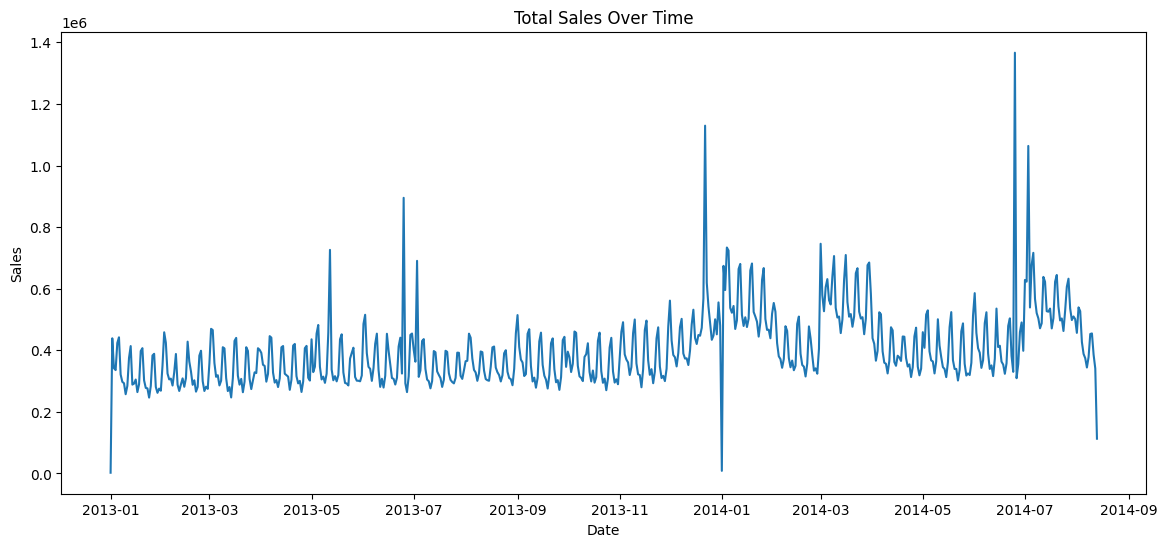

In [9]:
def time_series_analysis(df):
    print("\n ===== TIME SERIES ANALYSIS =====")

    # Aggregate daily sales (important!)
    daily_sales = df.groupby('date')['sales'].sum().reset_index()

    plt.figure(figsize=(14,6))
    plt.plot(daily_sales['date'], daily_sales['sales'])
    plt.title('Total Sales Over Time')
    plt.xlabel('Date')
    plt.ylabel('Sales')
    plt.show()


time_series_analysis(df)


 ===== CORRELATION ANALYSIS =====


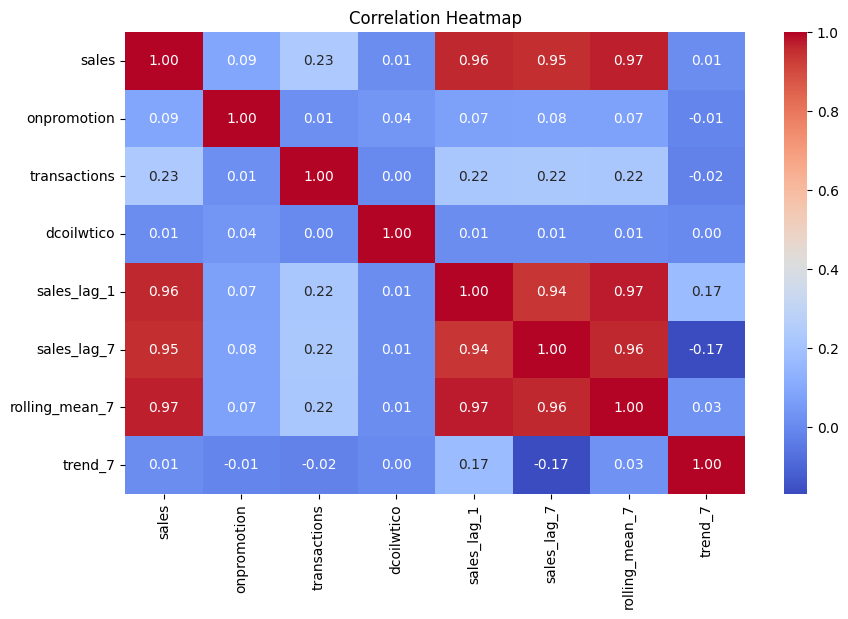

In [10]:
def correlation_analysis(df):
    print("\n ===== CORRELATION ANALYSIS =====")

    # Select important numeric columns
    corr_cols = [
        'sales', 'onpromotion', 'transactions', 'dcoilwtico',
        'sales_lag_1', 'sales_lag_7', 'rolling_mean_7',
        'trend_7'
    ]

    corr = df[corr_cols].corr()

    plt.figure(figsize=(10,6))
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation Heatmap')
    plt.show()


correlation_analysis(df)


 ===== SCATTER ANALYSIS =====


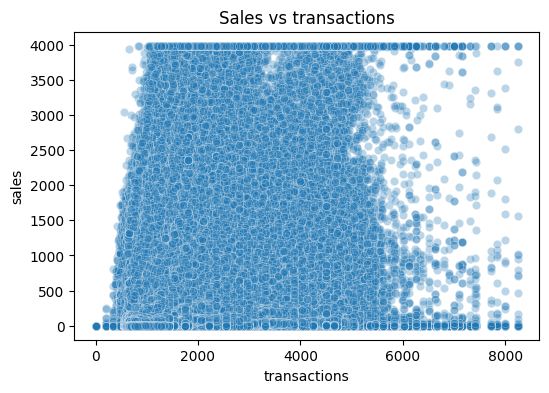

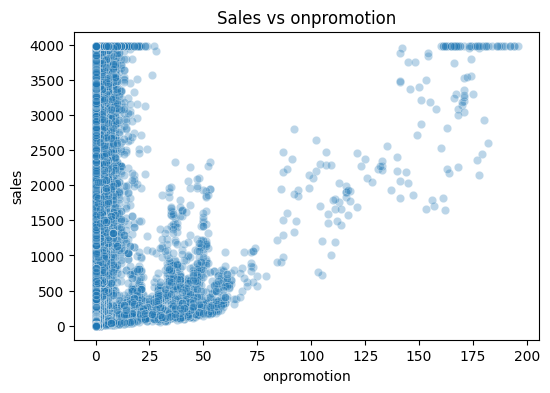

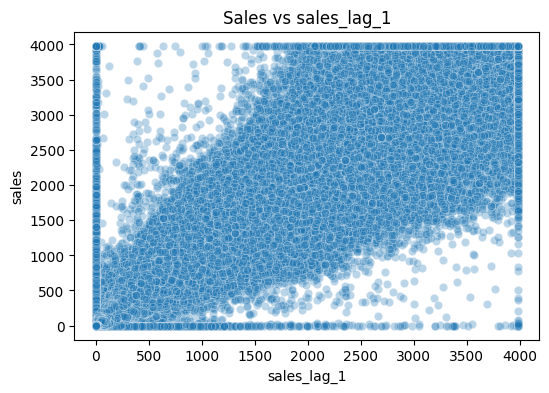

In [11]:
def scatter_analysis(df):
    print("\n ===== SCATTER ANALYSIS =====")

    features = ['transactions', 'onpromotion', 'sales_lag_1']

    for col in features:
        if col in df.columns:
            plt.figure(figsize=(6,4))
            sns.scatterplot(x=df[col], y=df['sales'], alpha=0.3)
            plt.title(f'Sales vs {col}')
            plt.show()


scatter_analysis(df)

In [12]:
# Feature columns used by the model (excludes target, date, and string keys)
FEATURE_COLS = [
    'store_nbr', 'family', 'onpromotion',
    'state', 'store_type', 'cluster',
    'dcoilwtico', 'transactions',
    'holiday_type', 'locale', 'transferred', 'is_holiday',
    'year', 'month', 'day', 'day_of_week', 'week_of_year',
    'is_weekend', 'month_sin', 'month_cos', 'week_sin', 'week_cos', 'half_year',
    'sales_lag_1', 'sales_lag_7', 'sales_lag_14', 'sales_lag_30',
    'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_30', 'rolling_std_7',
    'trend_7', 'trend_14',
    'promo_effect', 'holiday_promo'
]
TARGET_COL = 'sales'


def split_data(df, feature_cols, target_col, test_ratio=0.2):
    """
    Time-based train/test split — NO RANDOM SHUFFLING.

    Why no shuffle:
      Random splitting leaks future rows into training, producing
      inflated metrics that won't generalise to real future dates.
      Chronological split mirrors actual deployment conditions.

    Split: first 80% of rows = train, last 20% = test.
    """
    # Sort by store, family, then date to ensure chronological ordering
    df = df.sort_values(['store_nbr', 'family', 'year', 'month', 'day']).reset_index(drop=True)

    split_idx = int(len(df) * (1 - test_ratio))

    train_df = df.iloc[:split_idx]
    test_df  = df.iloc[split_idx:]

    X_train = train_df[feature_cols]
    y_train = train_df[target_col]
    X_test  = test_df[feature_cols]
    y_test  = test_df[target_col]

    print(f'Train size : {len(X_train):,} rows')
    print(f'Test size  : {len(X_test):,} rows')
    print(f'Features   : {len(feature_cols)}')
    return X_train, X_test, y_train, y_test


X_train, X_test, y_train, y_test = split_data(df, FEATURE_COLS, TARGET_COL)

Train size : 851,690 rows
Test size  : 212,923 rows
Features   : 35


In [13]:
print(df.isnull().sum())

date               0
store_nbr          0
family             0
sales              0
onpromotion        0
city               0
state              0
store_type         0
cluster            0
dcoilwtico         0
transactions       0
holiday_type       0
locale             0
transferred        0
is_holiday         0
year               0
month              0
day                0
day_of_week        0
week_of_year       0
is_weekend         0
half_year          0
month_sin          0
month_cos          0
week_sin           0
week_cos           0
sales_lag_1        0
sales_lag_7        0
sales_lag_14       0
sales_lag_30       0
rolling_mean_7     0
rolling_mean_14    0
rolling_mean_30    0
rolling_std_7      0
trend_7            0
trend_14           0
promo_effect       0
holiday_promo      0
store_family       0
dtype: int64


In [14]:
from sklearn.ensemble import RandomForestRegressor
import time

print(' Training FAST Random Forest...')

start = time.time()

rf_model = RandomForestRegressor(
    n_estimators=30,        # ↓ from 50 → faster
    max_depth=12,           # limit tree growth
    max_features='sqrt',    # faster splits
    n_jobs=-1,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_preds = np.clip(rf_model.predict(X_test), 0, None)

rf_time = time.time() - start

rf_mae  = mean_absolute_error(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
mean_s  = y_test.mean()

print(f'\n=== Random Forest (FAST) ===')
print(f'Time       : {rf_time:.1f}s')
print(f'MAE        : {rf_mae:.2f}')
print(f'RMSE       : {rf_rmse:.2f}')
print(f'MAE/Mean   : {rf_mae/mean_s*100:.1f}%')

 Training FAST Random Forest...

=== Random Forest (FAST) ===
Time       : 7.8s
MAE        : 42.96
RMSE       : 118.83
MAE/Mean   : 12.7%


In [15]:
from xgboost import XGBRegressor
import time
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

print('\nTraining FAST XGBoost...')

start = time.time()

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=0.1,
    tree_method='hist',
    n_jobs=-1,
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

xgb_preds = np.clip(xgb_model.predict(X_test), 0, None)

xgb_time = time.time() - start

xgb_mae = mean_absolute_error(y_test, xgb_preds)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))

print(f'\n=== XGBoost (FAST) ===')
print(f'Time       : {xgb_time:.1f}s')
print(f'MAE        : {xgb_mae:.2f}')
print(f'RMSE       : {xgb_rmse:.2f}')
print(f'MAE/Mean   : {xgb_mae/mean_s*100:.1f}%')


Training FAST XGBoost...

=== XGBoost (FAST) ===
Time       : 12.2s
MAE        : 38.89
RMSE       : 99.64
MAE/Mean   : 11.5%


In [16]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'MAE': [rf_mae, xgb_mae],
    'RMSE': [rf_rmse, xgb_rmse],
    'Time (s)': [rf_time, xgb_time]
})

print('\nModel Comparison:')
print(results)


Model Comparison:
           Model        MAE        RMSE   Time (s)
0  Random Forest  42.960290  118.832494   7.767292
1        XGBoost  38.891977   99.640688  12.197278


In [17]:
import optuna
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
import numpy as np

tscv = TimeSeriesSplit(n_splits=5)

def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 1000),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0, 5),

        "tree_method": "hist",
        "random_state": 42
    }

    maes = []

    for train_idx, val_idx in tscv.split(X_train):

        X_tr = X_train.iloc[train_idx]
        X_val = X_train.iloc[val_idx]
        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        model = XGBRegressor(**params)
        model.fit(X_tr, y_tr)

        preds = model.predict(X_val)
        preds = np.clip(preds, 0, None)

        maes.append(mean_absolute_error(y_val, preds))

    return np.mean(maes)

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

[I 2026-04-26 23:41:03,242] A new study created in memory with name: no-name-e4042a38-6b5e-4e5a-98d4-18763b063028
[I 2026-04-26 23:42:37,154] Trial 0 finished with value: 25.508158574042778 and parameters: {'n_estimators': 934, 'max_depth': 10, 'learning_rate': 0.025293436160806405, 'subsample': 0.8171329388285491, 'colsample_bytree': 0.9952187403513904, 'min_child_weight': 9, 'gamma': 0.2635686857459124}. Best is trial 0 with value: 25.508158574042778.
[I 2026-04-26 23:44:48,137] Trial 1 finished with value: 24.00970366624407 and parameters: {'n_estimators': 963, 'max_depth': 11, 'learning_rate': 0.010662165252605042, 'subsample': 0.6118545487327792, 'colsample_bytree': 0.7874044189852251, 'min_child_weight': 7, 'gamma': 1.3675184445399946}. Best is trial 1 with value: 24.00970366624407.
[I 2026-04-26 23:45:31,762] Trial 2 finished with value: 29.80597265350849 and parameters: {'n_estimators': 797, 'max_depth': 4, 'learning_rate': 0.08171788456239452, 'subsample': 0.9560245856202988, 

In [18]:
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Training final model using Optuna best params...")

# ── Get best params from Optuna ─────────────────
best_params = study.best_params.copy()

# Add stable settings
best_params.update({
    "tree_method": "hist",
    "random_state": 42
})

print("\nBest Parameters Found:")
for k, v in best_params.items():
    print(f"{k}: {v}")

# ── Train final model ───────────────────────────
final_model = XGBRegressor(**best_params)
final_model.fit(X_train, y_train)

# ── Predictions ────────────────────────────────
preds = final_model.predict(X_test)
preds = np.clip(preds, 0, None)   # avoid negative sales

# ── Metrics ────────────────────────────────────
mae  = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2   = r2_score(y_test, preds)
mean_s = np.mean(y_test)

# ── Results ────────────────────────────────────
print("\n=== Final Optuna-Tuned XGBoost Model ===")
print(f"MAE        : {mae:.2f}")
print(f"RMSE       : {rmse:.2f}")
print(f"R2         : {r2:.4f}")
print(f"Mean Sales : {mean_s:.2f}")
print(f"MAE/Mean   : {mae/mean_s*100:.1f}%")

Training final model using Optuna best params...

Best Parameters Found:
n_estimators: 824
max_depth: 12
learning_rate: 0.02009784375767591
subsample: 0.9589680810361173
colsample_bytree: 0.618586194334579
min_child_weight: 2
gamma: 0.7442348573721431
tree_method: hist
random_state: 42

=== Final Optuna-Tuned XGBoost Model ===
MAE        : 34.46
RMSE       : 97.56
R2         : 0.9856
Mean Sales : 338.54
MAE/Mean   : 10.2%


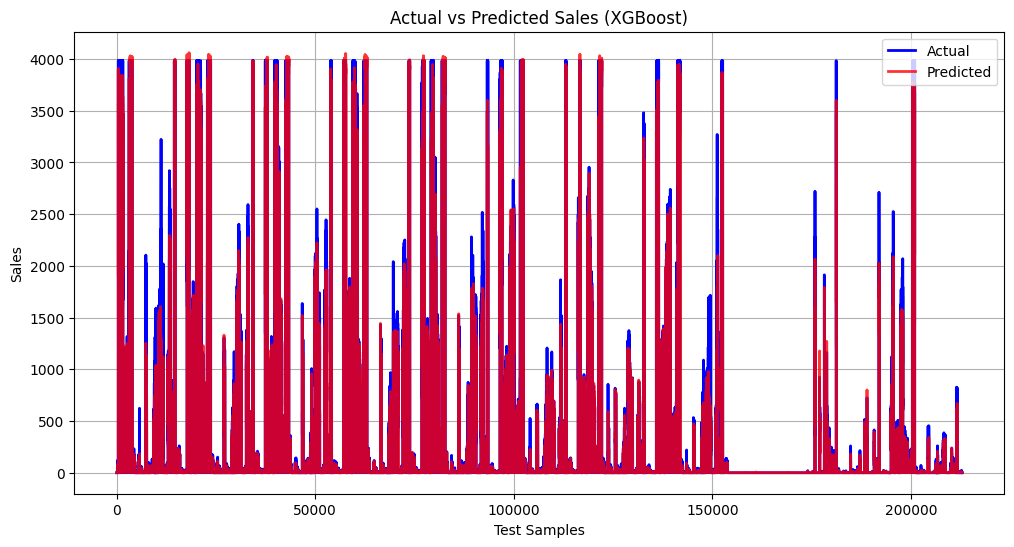

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(y_test.values, label="Actual", color="blue", linewidth=2)
plt.plot(preds, label="Predicted", color="red", linewidth=2, alpha=0.8)

plt.title("Actual vs Predicted Sales (XGBoost)")
plt.xlabel("Test Samples")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.show()

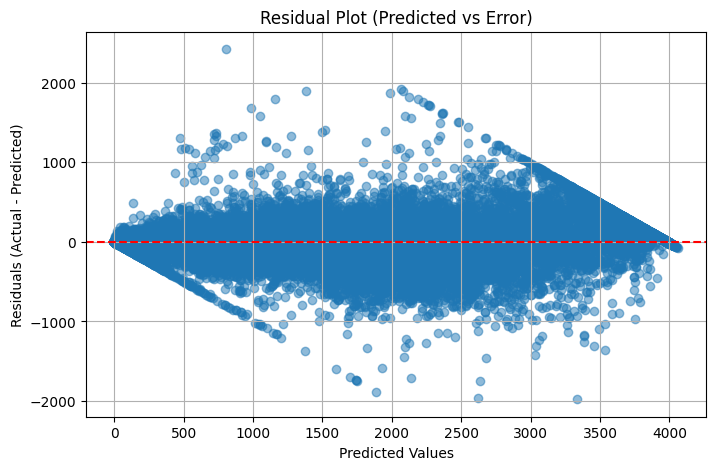

In [22]:
import numpy as np

residuals = y_test.values - preds

plt.figure(figsize=(8,5))

plt.scatter(preds, residuals, alpha=0.5)
plt.axhline(0, color="red", linestyle="--")

plt.title("Residual Plot (Predicted vs Error)")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.grid(True)

plt.show()

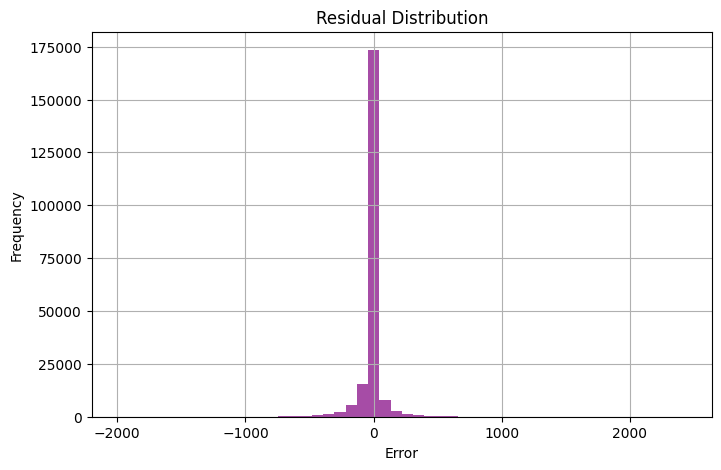

In [23]:
plt.figure(figsize=(8,5))

plt.hist(residuals, bins=50, color="purple", alpha=0.7)

plt.title("Residual Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.grid(True)

plt.show()

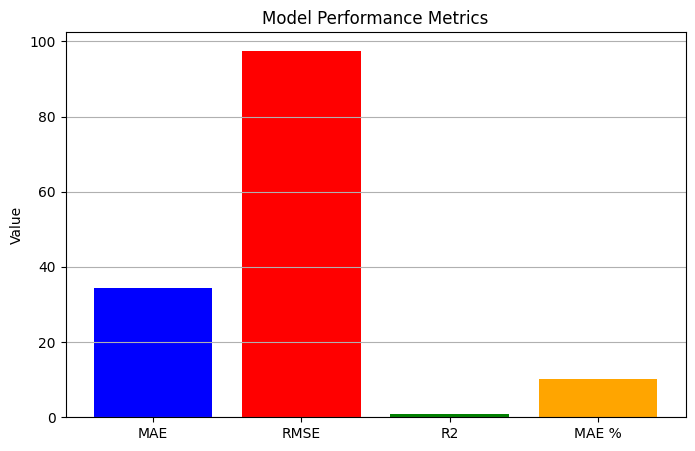

In [24]:
import matplotlib.pyplot as plt

metrics = {
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2,
    "MAE %": mae / mean_s * 100
}

names = list(metrics.keys())
values = list(metrics.values())

plt.figure(figsize=(8,5))

plt.bar(names, values, color=["blue", "red", "green", "orange"])

plt.title("Model Performance Metrics")
plt.ylabel("Value")
plt.grid(axis="y")

plt.show()

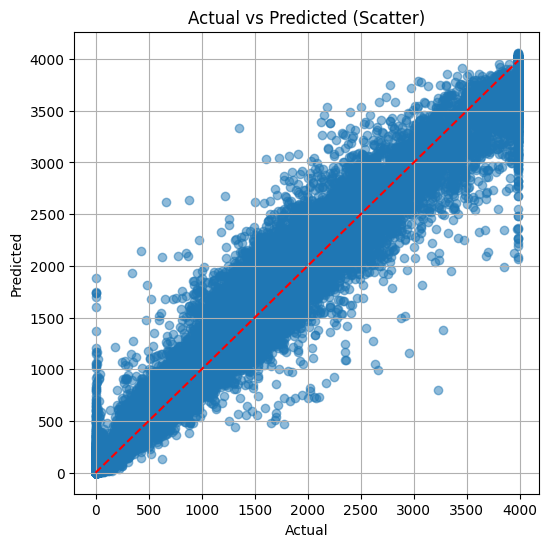

In [25]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, preds, alpha=0.5)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red", linestyle="--")

plt.title("Actual vs Predicted (Scatter)")
plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.grid(True)

plt.show()

In [12]:
import joblib

joblib.dump(final_model, "model.pkl")
joblib.dump(encoders, "encoders.pkl")

print(" Model and encoders saved!")

✅ Model and encoders saved!


In [ ]:
import joblib
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import os

def run_pipeline(n_estimators=300, save_model=True):
    print("\n===== RUNNING FULL PIPELINE =====\n")

    # 1. Load
    train, stores, oil, transactions, holidays = load_data()

    # 2. Merge
    df = merge_data(train, stores, oil, transactions, holidays)

    # 3. Clean
    df = clean_data(df)

    # 4. Encode
    df, encoders = encode_categoricals(df)

    # 5. Feature Engineering
    df = engineer_features(df)

    # 6. Split
    X_train, X_test, y_train, y_test = split_data(df, FEATURE_COLS, TARGET_COL)

    # 7. Model
    print("\nTraining XGBoost model...")

    model = XGBRegressor(
        n_estimators=n_estimators,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method='hist',
        n_jobs=-1,
        random_state=42
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False,
        early_stopping_rounds=30
    )

    # 8. Predictions
    preds = np.clip(model.predict(X_test), 0, None)

    # 9. Metrics
    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mean_s = y_test.mean()

    print("\n===== FINAL RESULTS =====")
    print(f"MAE        : {mae:.2f}")
    print(f"RMSE       : {rmse:.2f}")
    print(f"MAE/Mean   : {mae/mean_s*100:.1f}%")

    # 10. Save model
    if save_model:
        os.makedirs("artifacts", exist_ok=True)

        joblib.dump(model, "artifacts/xgb_model.pkl")
        joblib.dump(encoders, "artifacts/encoders.pkl")

        print("\nModel saved to /artifacts/")

    return model, encoders